In [22]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY


In [23]:
# 훈련세트 테스트세트 분할
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,random_state=42)

# 이상치 탐지 라이브러리
# 정상데이터보다 이상치는 더 쉽게(적은 분할로) 고립된다
# 랜던하게 feature선택 랜덤하게 split value 선택 -> 계속.. 어떤 데이터가 얼마나 빨리 고립되는가
# 트리알고리즘, 이상치는 적은 분할회수로고립, 트리가 깊지 않음
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(random_state=42)
housing_numeric_for_outlier = train_set.drop('ocean_proximity',axis=1).dropna()
housing_numeric_for_outlier.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0


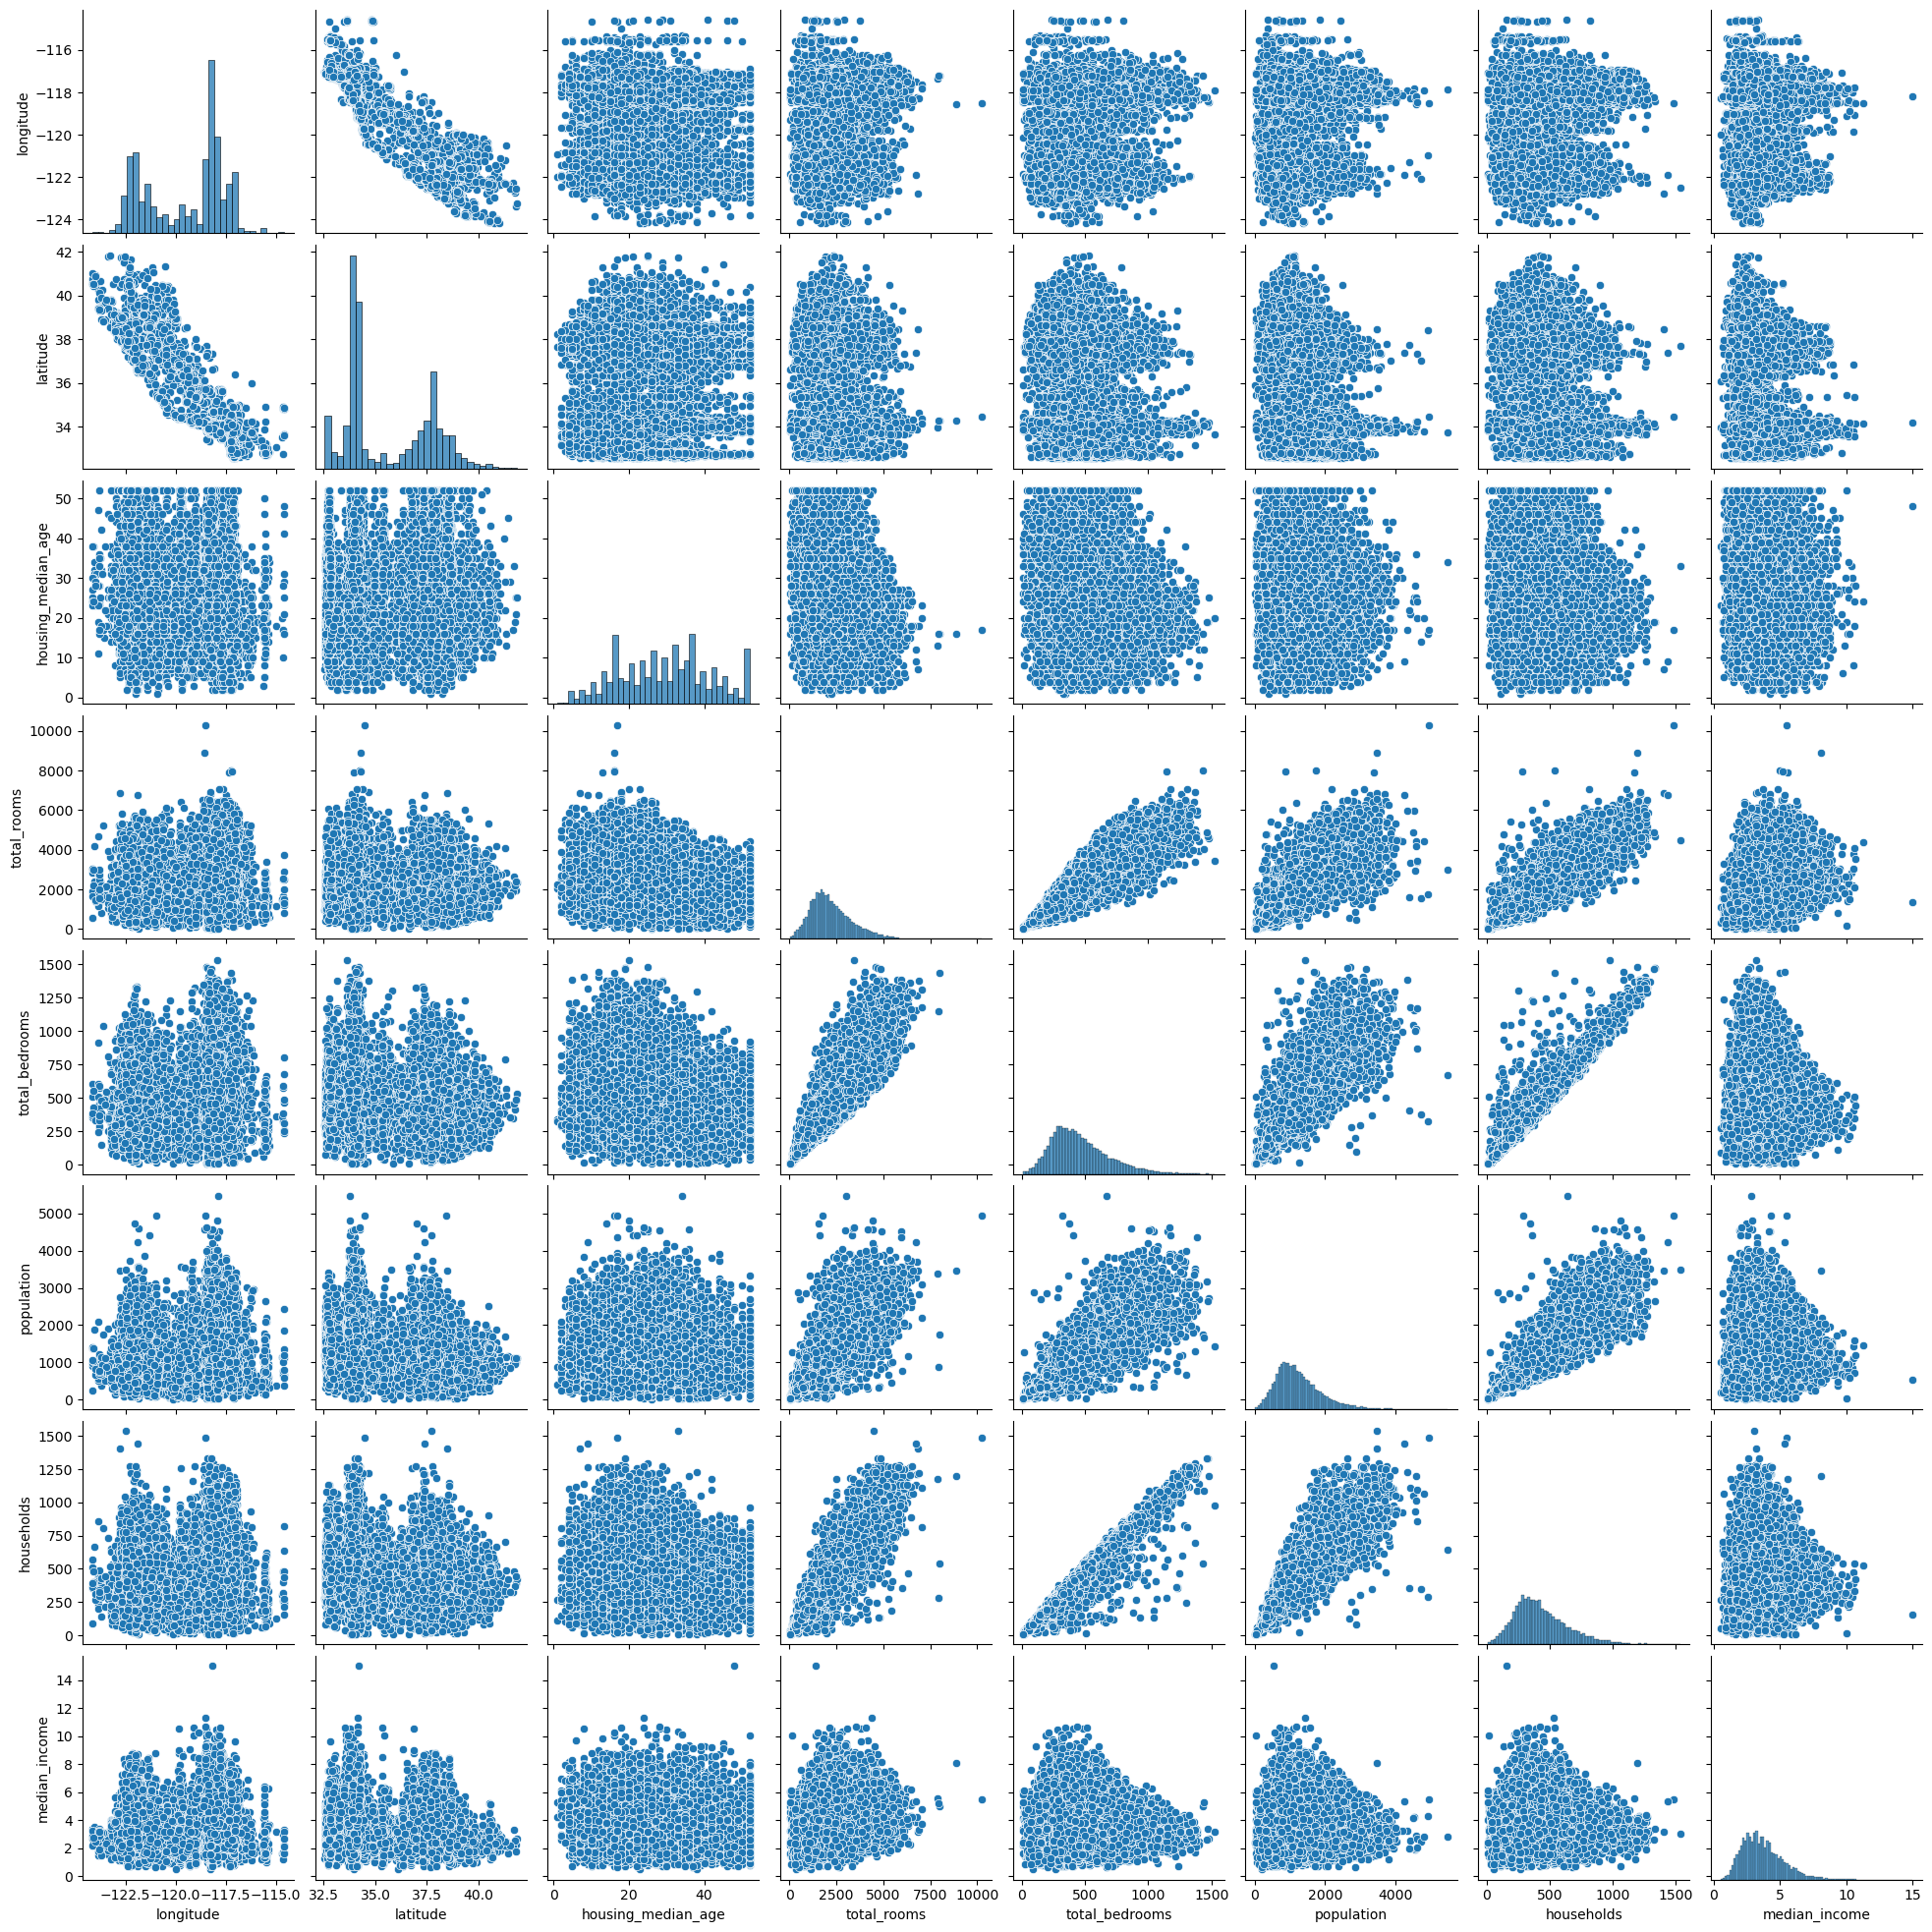

In [24]:
outlier_pred = pd.Series(1,index = train_set.index)
outlier_pred.loc[housing_numeric_for_outlier.index] = isolation_forest.fit_predict(housing_numeric_for_outlier)
# 정상 1 이상치 -1
train_set_clean = train_set[outlier_pred == 1]

# x y 분리
train_set_clean
housing = train_set_clean.drop('median_house_value',axis=1)  #정답제거된 학습용 데이터
housing_label = train_set_clean['median_house_value'].copy()  # 정답

# 데이터의 분포가 한쪽으로 치우쳐진 즉 꼬리가긴 왜도를 찾기
import seaborn as sns
sns.pairplot(housing)

In [27]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')

In [33]:
import numpy as np
#왜도 컬럼
skewed_attribs =  ['total_rooms','total_bedrooms', 'population','households','median_income']
#수치형 컬럼
num_attribs = ['longitude','latitude','housing_median_age']
# 범주형 컬럼
cat_attribs = ['ocean_proximity']

# 파이프라인
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler',StandardScaler())
])
# 범주형 부분과 최종 파이프라인
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ('num',num_pipeline,num_attribs),
    ('log',log_pipeline,skewed_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

# 모델 선택
from sklearn.ensemble import RandomForestRegressor
full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])
# 훈련
full_pipeline.fit(housing,housing_label)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [35]:
full_pipeline.score(test_set.drop('median_house_value',axis=1),test_set['median_house_value'])

0.8089169059009034